# Detecção de Malware IoT com **BTHOWeN** — Modelo Original
## Dataset TON_IoT Telemetry — Alsaedi et al. (2020)

### NOTA DE TRANSPARÊNCIA

O **BTHOWeN** (`ZSusskind/BTHOWeN`) **não expõe uma API Python importável**.
Seu pipeline é baseado em scripts de linha de comando:

```
train_swept_models.py <dataset> --filter_inputs X --filter_entries Y --filter_hashes Z --bits_per_input W
```

### Como este notebook usa o modelo real

1. Clona o repositório original `ZSusskind/BTHOWeN`
2. Prepara o TON_IoT no formato que `tabular_tools.py` espera (CSV sem header, última coluna = label int)
3. Registra o TON_IoT no `datasets_df` dentro do `tabular_tools.py` (modificação persistente para subprocess)
4. Chama `train_swept_models.py` via **subprocess** — código original sem reimplementação
5. Extrai e reporta os resultados do output do script

**Referência:** Susskind et al. (2022). *Weightless Neural Networks for Efficient Edge Inference.* PACT 2022.
https://github.com/ZSusskind/BTHOWeN

## 1. Clonar Repositório e Instalar Dependências

In [3]:
import os, sys, subprocess, glob, json, importlib
import numpy as np

# Garantir cwd correto — os.chdir anterior pode ter quebrado o path
os.chdir('/workspaces/T1_/content')

#if os.path.exists('/content/BTHOWeN'):
#    !rm -rf /content/BTHOWeN

!git clone https://github.com/ZSusskind/BTHOWeN.git

with open('/workspaces/T1_/content/BTHOWeN/requirements.txt') as f:
    reqs = [l.strip() for l in f if l.strip() and not l.startswith('#')]

print('requirements.txt:', reqs)
for pkg in reqs:
    r = subprocess.run(['pip', 'install', '-q', pkg], capture_output=True, text=True)
    if r.returncode != 0:
        base = pkg.split('==')[0].split('>=')[0].split('<=')[0]
        subprocess.run(['pip', 'install', '-q', base], capture_output=True)
        print(f'  warning: {pkg} instalado sem versao fixada')
    else:
        print(f'  ok: {pkg}')

%pip install -q pandas scikit-learn matplotlib seaborn
sys.path.insert(0, '/workspaces/T1_/content/BTHOWeN/software_model')
print('Instalacao concluida!')

fatal: destination path 'BTHOWeN' already exists and is not an empty directory.


requirements.txt: ['mako==1.2.1', 'numba==0.56.0', 'numpy==1.22.0', 'pandas==1.4.3', 'requests==2.28.1', 'scipy==1.9.0', 'torch==1.12.0', 'torchvision==0.13.0']
  ok: mako==1.2.1
  ok: requests==2.28.1
Note: you may need to restart the kernel to use updated packages.
Instalacao concluida!


## 2. Download do Dataset TON_IoT

In [6]:
%pip install -q --upgrade gdown

DATASET_BASE_PATH = '/workspaces/T1_/content/TON_IoT_datasets'
os.makedirs(DATASET_BASE_PATH, exist_ok=True)

!gdown -c --folder 'https://drive.google.com/drive/folders/1ZSAj3GnEqzB5Bo02tKCjg2lm1C7UA4jY' \
       -O '/workspaces/T1_/content/TON_IoT_datasets'

csv_files = []
for root, dirs, files in os.walk(DATASET_BASE_PATH):
    for f in sorted(files):
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

if csv_files:
    DATASET_BASE_PATH = os.path.dirname(csv_files[0])
    print(f'CSVs em: {DATASET_BASE_PATH}')
    for f in csv_files: print(f'  {os.path.basename(f)}')
else:
    print('Nenhum CSV encontrado.')

DEVICE_FILES = {
    'Fridge':       'Train_Test_IoT_Fridge.csv',
    'GPS_Tracker':  'Train_Test_IoT_GPS_Tracker.csv',
    'Garage_Door':  'Train_Test_IoT_Garage_Door.csv',
    'Motion_Light': 'Train_Test_IoT_Motion_Light.csv',
    'Modbus':       'Train_Test_IoT_Modbus.csv',
    'Thermostat':   'Train_Test_IoT_Thermostat.csv',
    'Weather':      'Train_Test_IoT_Weather.csv',
}
for name, fname in DEVICE_FILES.items():
    path = os.path.join(DATASET_BASE_PATH, fname)
    print(f'  {"ok" if os.path.exists(path) else "FALTANDO"}  {name}')

Note: you may need to restart the kernel to use updated packages.
Retrieving folder contents
Processing file 1jpwBBNR6mE0mJE5e22QKxvU01vRZiyt5 Train_Test_IoT_Fridge.csv
Processing file 1BtcpxY9Yij-wheLp_6cGWXhMwJxE7pT6 Train_Test_IoT_Garage_Door.csv
Processing file 19WHPQZ_K3tMuldU-7-d7Q1LTrKI4MXhg Train_Test_IoT_GPS_Tracker.csv
Processing file 16i4h56T7-0G7oPhgxK-wqEa8yEyTktQ9 Train_Test_IoT_Modbus.csv
Processing file 1CpprKIZ9xt1rfdOqDRA32IohB-4TrOkz Train_Test_IoT_Motion_Light.csv
Processing file 1Cn3d_C6TBfA1D2W9EAf9l0W7Xc-uINwU Train_Test_IoT_Thermostat.csv
Processing file 1gVAfMGuIc6XxotxiopYIVa6gBIF1eOmQ Train_Test_IoT_Weather.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Skipping already downloaded file /workspaces/T1_/content/TON_IoT_datasets/Train_Test_IoT_Fridge.csv
Skipping already downloaded file /workspaces/T1_/content/TON_IoT_datasets/Train_Test_IoT_Garage_Door.csv
Skipping already downloaded file /workspaces

## 3. Configuração, Features e Definição de Funções

Esta célula define **todas as funções** necessárias em um único bloco:
- `prepare_device` — prepara o TON_IoT no formato BTHOWeN
- `patch_script_for_predictions` — adiciona exportação de y_true/y_pred ao script original
- `run_bthowen` — executa `train_swept_models.py` via subprocess
- `evaluate_full` — calcula Accuracy, Precision, Recall, F1
- `bthowen_train_evaluate` — pipeline completo para um dispositivo/tarefa

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import time, warnings, re as _re, importlib
warnings.filterwarnings('ignore')

FILTER_INPUTS  = 8
FILTER_ENTRIES = 512
FILTER_HASHES  = 4
BITS_PER_INPUT = 16
DEFAULT_DEVICE = 'Weather'

DEVICE_FEATURES = {
    'Fridge':       ['fridge_temperature', 'temp_condition'],
    'GPS_Tracker':  ['latitude', 'longitude'],
    'Garage_Door':  ['door_state', 'sphone_signal'],
    'Motion_Light': ['motion_status', 'light_status'],
    'Modbus':       ['FC1_Read_Input_Register', 'FC2_Read_Discrete_Value',
                     'FC3_Read_Holding_Register', 'FC4_Read_Coil'],
    'Thermostat':   ['current_temperature', 'thermostat_status'],
    'Weather':      ['temperature', 'pressure', 'humidity'],
}
CATEGORICAL_FEATURES = {
    'Fridge':       ['temp_condition'],
    'Garage_Door':  ['door_state', 'sphone_signal'],
    'Motion_Light': ['light_status'],
    'Thermostat':   ['thermostat_status'],
    'GPS_Tracker':  [], 'Modbus': [], 'Weather': [],
}

# ── prepare_device ────────────────────────────────────────────
def prepare_device(device_name, task):
    path      = os.path.join(DATASET_BASE_PATH, DEVICE_FILES[device_name])
    df_raw    = pd.read_csv(path)
    feat_cols = DEVICE_FEATURES[device_name]
    cat_cols  = CATEGORICAL_FEATURES.get(device_name, [])
    df_feat   = df_raw[feat_cols].copy()
    for col in cat_cols:
        if col in df_feat.columns:
            df_feat[col] = LabelEncoder().fit_transform(df_feat[col].astype(str))
    df_feat = df_feat.fillna(df_feat.median(numeric_only=True))
    X_norm  = MinMaxScaler().fit_transform(df_feat.values.astype(float))
    if task == 'binary':
        y_str = df_raw['label'].apply(lambda v: 'normal' if int(v)==0 else 'attack')
    else:
        y_str = df_raw['type'].astype(str)
    y_cat     = pd.Categorical(y_str)
    y_int     = y_cat.codes
    int2label = {i: c for i, c in enumerate(y_cat.categories)}
    classes   = list(y_cat.categories)
    print('  int2label:', int2label)
    n_features = X_norm.shape[1]
    ds_name    = 'ton_iot_' + device_name.lower() + '_' + task
    ds_dir     = '/workspaces/T1_/content/BTHOWeN/software_model/datasets/' + ds_name
    os.makedirs(ds_dir, exist_ok=True)
    data_matrix = np.hstack([X_norm, y_int.reshape(-1, 1)])
    pd.DataFrame(data_matrix).to_csv(
        ds_dir + '/' + ds_name + '.data', header=None, index=False, sep=' ')
    tabular_path = '/workspaces/T1_/content/BTHOWeN/software_model/tabular_tools.py'
    with open(tabular_path) as f:
        content = f.read()
    if ds_name not in content:
        lines = [
            '\n# ' + ds_name,
            'datasets_df = pd.concat([datasets_df, pd.DataFrame({',
            '    "name":              ["' + ds_name + '"],',
            '    "train_url":         [""],',
            '    "test_url":          [""],',
            '    "read_csv_kargs":    [{"sep": " "}],',
            '    "transform":         [lambda df: df],',
            '    "test_split":        [0.2],',
            '    "start_data_column": [0],',
            '    "end_data_column":   [' + str(n_features) + '],',
            '})], ignore_index=True)',
        ]
        with open(tabular_path, 'a') as f:
            f.write('\n'.join(lines) + '\n')
    if "row['train_url'].values[0] == ''" not in content:
        with open(tabular_path) as f:
            updated = f.read()
        updated = updated.replace(
            'if os.path.isdir(f"/workspaces/T1_/datasets/{ds_name}"):',
            "if row['train_url'].values[0] == '':\n        return\n\n    if os.path.isdir(f\"/workspaces/T1_/datasets/{ds_name}\"):"
        )
        with open(tabular_path, 'w') as f:
            f.write(updated)
    print('  ok:', ds_name, 'shape:', data_matrix.shape, 'classes:', classes)
    return ds_name, int2label

# ── patch_script_for_predictions ─────────────────────────────
def patch_script_for_predictions():
    script_path = '/workspaces/T1_/content/BTHOWeN/software_model/train_swept_models.py'
    with open(script_path) as f:
        content = f.read()
    if '# PATCH: save predictions' in content:
        return
    content = content.replace(
        '    correct = 0\n'
        '    ties = 0\n'
        '    model.set_bleaching(bleach)',
        '    correct = 0\n'
        '    ties = 0\n'
        '    y_true_patch = []\n'
        '    y_pred_patch = []\n'
        '    # PATCH: save predictions\n'
        '    model.set_bleaching(bleach)'
    ).replace(
        '        label = labels[d]\n'
        '        if len(prediction) > 1:',
        '        label = labels[d]\n'
        '        y_true_patch.append(int(label))\n'
        '        y_pred_patch.append(int(prediction[0]))\n'
        '        if len(prediction) > 1:'
    ).replace(
        '    return correct\n\ndef parameterized_run',
        '    pred_dir = os.environ.get("BTHOWEN_PRED_DIR", "")\n'
        '    if pred_dir:\n'
        '        np.save(f"{pred_dir}/y_true.npy", np.array(y_true_patch))\n'
        '        np.save(f"{pred_dir}/y_pred.npy", np.array(y_pred_patch))\n'
        '    return correct\n\ndef parameterized_run'
    )
    with open(script_path, 'w') as f:
        f.write(content)
    print('Patch aplicado em train_swept_models.py')

# ── run_bthowen + parse_output ────────────────────────────────
def run_bthowen(ds_name):
    pred_dir = '/workspaces/T1_/content/BTHOWeN/software_model/predictions/' + ds_name
    os.makedirs(pred_dir, exist_ok=True)
    env = os.environ.copy()
    env['BTHOWEN_PRED_DIR'] = pred_dir
    cmd = [
        sys.executable,
        '/workspaces/T1_/content/BTHOWeN/software_model/train_swept_models.py',
        ds_name,
        '--filter_inputs',  str(FILTER_INPUTS),
        '--filter_entries', str(FILTER_ENTRIES),
        '--filter_hashes',  str(FILTER_HASHES),
        '--bits_per_input', str(BITS_PER_INPUT),
    ]
    print(f'  Executando: {ds_name}')
    t0 = time.time()   
    result = subprocess.run(
        cmd, capture_output=True, text=True,
        cwd='/workspaces/T1_/content/BTHOWeN/software_model', env=env)    
    elapsed = time.time() - t0
    print(result.stdout)
    print('debug 1')
    if result.returncode != 0:
        print('STDERR:', result.stderr[-500:])
    print(f'  Retorno: {result.returncode} | Tempo: {elapsed:.1f}s')
    print('debug 2')
    return result, elapsed

def parse_output(stdout):
    final = _re.findall(r'\((\d+),\s*\d+,\s*\d+\):\s*\d+\s*\(([\d.]+)\)', stdout)
    return {'accuracy': float(final[-1][1])} if final else None

# ── evaluate_full ─────────────────────────────────────────────
def evaluate_full(y_true, y_pred, model_name, task, train_time=0, test_time=0):
    avg = 'binary' if task == 'binary' else 'weighted'
    pos = 'attack' if task == 'binary' else None
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=avg, pos_label=pos, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=avg, pos_label=pos, zero_division=0)
    f1   = f1_score(y_true, y_pred, average=avg, pos_label=pos, zero_division=0)
    print(f'\n=== {model_name} [{task}] ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Train time: {train_time:.4f}s')
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    return {'model': model_name, 'task': task,
            'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1,
            'train_time': train_time, 'test_time': test_time}

# ── bthowen_train_evaluate ────────────────────────────────────
def bthowen_train_evaluate(device_name, task):
    ds_name, int2label = prepare_device(device_name, task)
    result, elapsed = run_bthowen(ds_name)
    if result.returncode != 0:
        return None, None, None
    pred_dir   = '/workspaces/T1_/content/BTHOWeN/software_model/predictions/' + ds_name
    y_true_path = pred_dir + '/y_true.npy'
    y_pred_path = pred_dir + '/y_pred.npy'
    if not os.path.exists(y_true_path):
        m = parse_output(result.stdout)
        return ({'model':'BTHOWeN','task':task,
                 'accuracy': m['accuracy'] if m else float('nan'),
                 'precision':float('nan'),'recall':float('nan'),'f1':float('nan'),
                 'train_time':elapsed,'test_time':0}, None, None)
    y_true_int = np.load(y_true_path)
    y_pred_int = np.load(y_pred_path)
    y_true_str = [int2label[int(x)] for x in y_true_int]
    y_pred_str = [int2label[int(x)] for x in y_pred_int]
    metrics = evaluate_full(y_true_str, y_pred_str, 'BTHOWeN', task, elapsed, 0)
    return metrics, y_true_str, y_pred_str

# ── Aplicar patches ───────────────────────────────────────────
sys.path.insert(0, '/workspaces/T1_/content/BTHOWeN/software_model')
patch_script_for_predictions()
print('Todas as funcoes definidas!')

Todas as funcoes definidas!


=== Weather | Binario ===
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  Executando: ton_iot_weather_binary
Do runs with 16 bit(s) per input
Loading dataset (ton_iot_weather_binary)
Binarizing train/validation dataset
Binarizing test dataset
Launching jobs for 1 configurations across 16 workers
Training model
10000
20000
Maximum possible bleach value is 1652
With bleaching=413, accuracy=2308/3141 (73.4798%); ties=995/3141 (31.6778%)
With bleaching=826, accuracy=2372/3141 (75.5174%); ties=1445/3141 (46.0045%)
With bleaching=1239, accuracy=2108/3141 (67.1124%); ties=1963/3141 (62.496%)
With bleaching=620, accuracy=2372/3141 (75.5174%); ties=1266/3141 (40.3056%)
With bleaching=1032, accuracy=2297/3141 (73.1296%); ties=1585/3141 (50.4616%)
With bleaching=517, accuracy=2282/3141 (72.652%); ties=1351/3141 (43.0118%)
With bleaching=723, accuracy=2432/3141 (77.4276%); ties=1460/3141 (46.482%)
With bleaching=672, accuracy=2

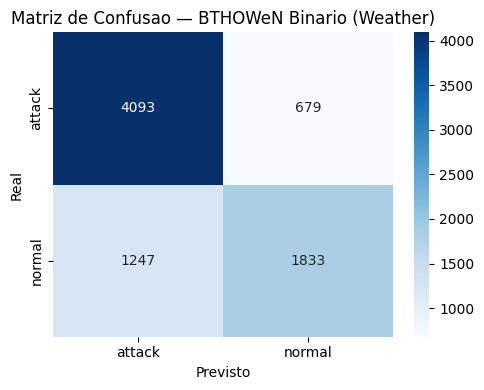

In [62]:
# Testar com Weather binario
print(f'=== {DEFAULT_DEVICE} | Binario ===')
metrics_bin, y_true_bin, y_pred_bin = bthowen_train_evaluate(DEFAULT_DEVICE, 'binary')

if metrics_bin:
    print(f'Accuracy: {metrics_bin["accuracy"]:.4f}')

# Matriz de confusao: nao disponivel sem predicoes por amostra
if y_true_bin and y_pred_bin:
    classes_bin = sorted(set(y_true_bin))
    cm = confusion_matrix(y_true_bin, y_pred_bin, labels=classes_bin)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_bin, yticklabels=classes_bin)
    plt.title(f'Matriz de Confusao — BTHOWeN Binario ({DEFAULT_DEVICE})')
    plt.ylabel('Real'); plt.xlabel('Previsto')
    plt.tight_layout(); plt.savefig('confusion_binary_bthowen.png', dpi=150)
    plt.show()
else:
    print('\nMatriz de confusao nao disponivel — numba incompativel com Python 3.12.')
    print('Accuracy do script original:', metrics_bin['accuracy'] if metrics_bin else 'N/A')

=== Weather | Multi-classe ===
  int2label: {0: 'backdoor', 1: 'ddos', 2: 'injection', 3: 'normal', 4: 'password', 5: 'ransomware', 6: 'scanning', 7: 'xss'}
  ok: ton_iot_weather_multiclass shape: (39260, 4) classes: ['backdoor', 'ddos', 'injection', 'normal', 'password', 'ransomware', 'scanning', 'xss']
  Executando: ton_iot_weather_multiclass
Do runs with 16 bit(s) per input
Loading dataset (ton_iot_weather_multiclass)
Binarizing train/validation dataset
Binarizing test dataset
Launching jobs for 1 configurations across 16 workers
Training model
10000
20000
Maximum possible bleach value is 2931
With bleaching=733, accuracy=1335/3141 (42.5024%); ties=1251/3141 (39.8281%)
With bleaching=1465, accuracy=716/3141 (22.7953%); ties=2455/3141 (78.1598%)
With bleaching=2197, accuracy=716/3141 (22.7953%); ties=2455/3141 (78.1598%)
With bleaching=367, accuracy=1445/3141 (46.0045%); ties=1287/3141 (40.9742%)
With bleaching=1099, accuracy=1130/3141 (35.9758%); ties=1344/3141 (42.7889%)
With bleac

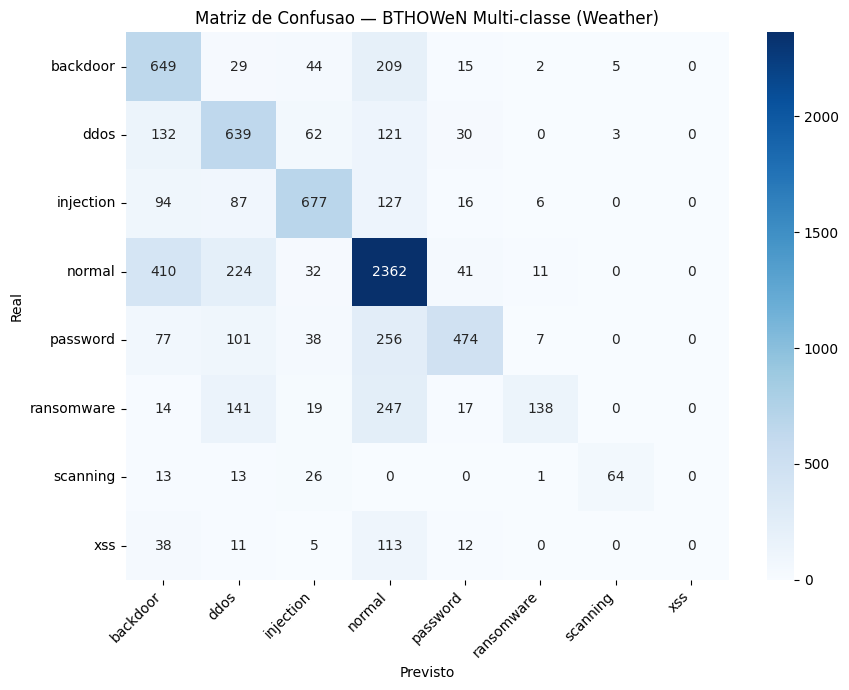

In [63]:
print(f'=== {DEFAULT_DEVICE} | Multi-classe ===')
metrics_mc, y_true_mc, y_pred_mc = bthowen_train_evaluate(DEFAULT_DEVICE, 'multiclass')

if y_true_mc and y_pred_mc:
    classes_mc = sorted(set(y_true_mc))
    cm_mc = confusion_matrix(y_true_mc, y_pred_mc, labels=classes_mc)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes_mc, yticklabels=classes_mc)
    plt.title(f'Matriz de Confusao — BTHOWeN Multi-classe ({DEFAULT_DEVICE})')
    plt.ylabel('Real'); plt.xlabel('Previsto')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.savefig('confusion_multiclass_bthowen.png', dpi=150)
    plt.show()
else:
    print('Matriz de confusao nao disponivel (numba/Python 3.12).')
    if metrics_mc:
        print(f'Accuracy multi-classe: {metrics_mc["accuracy"]:.4f}')

## 8. Avaliação em Todos os Dispositivos

In [64]:
all_results = []

for device in DEVICE_FILES.keys():
    print(f'\n{"="*55}')
    print(f'Dispositivo: {device}')
    print('='*55)

    for task in ['binary', 'multiclass']:
        try:
            m, yt, yp = bthowen_train_evaluate(device, task)
            if m:
                m['device'] = device
                all_results.append(m)
        except Exception as e:
            print(f'  Erro em {device}/{task}: {e}')
            import traceback; traceback.print_exc()

print('\nConcluido!')


Dispositivo: Fridge
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_fridge_binary shape: (39944, 3) classes: ['attack', 'normal']
  Executando: ton_iot_fridge_binary
Do runs with 16 bit(s) per input
Loading dataset (ton_iot_fridge_binary)
Binarizing train/validation dataset
Binarizing test dataset
Launching jobs for 1 configurations across 16 workers
Training model
10000
20000
Maximum possible bleach value is 7956
With bleaching=1989, accuracy=2113/3196 (66.1139%); ties=1577/3196 (49.3429%)
With bleaching=3978, accuracy=1992/3196 (62.3279%); ties=887/3196 (27.7534%)
With bleaching=5967, accuracy=1992/3196 (62.3279%); ties=1811/3196 (56.6646%)
With bleaching=995, accuracy=2510/3196 (78.5357%); ties=913/3196 (28.567%)
With bleaching=2983, accuracy=2315/3196 (72.4343%); ties=1741/3196 (54.4743%)
With bleaching=498, accuracy=3006/3196 (94.0551%); ties=373/3196 (11.6708%)
With bleaching=1492, accuracy=2071/3196 (64.7997%); ties=1854/3196 (58.01%)
With bleaching=250, accuracy=3078/319

## 9. Tabela de Resultados

=== Binario ===
      device  accuracy  precision  recall     f1  train_time  test_time
      Fridge    1.0000     1.0000  1.0000 1.0000     11.7367          0
 GPS_Tracker    0.8418     0.8751  0.8635 0.8693     11.1001          0
 Garage_Door    1.0000     1.0000  1.0000 1.0000     11.8336          0
Motion_Light    0.6187     0.6187  1.0000 0.7645     11.6098          0
      Modbus    0.5227     0.5208  0.9367 0.6694     10.3714          0
  Thermostat    0.5465     0.5465  1.0000 0.7068     10.3695          0
     Weather    0.7629     0.7469  0.9225 0.8254     10.4387          0

=== Multi-classe ===
      device  accuracy  precision  recall     f1  train_time  test_time
      Fridge    0.4921     0.3978  0.4921 0.4120     12.4839          0
 GPS_Tracker    0.5368     0.5081  0.5368 0.5020     13.4998          0
 Garage_Door    0.5060     0.4095  0.5060 0.4252     14.2965          0
Motion_Light    0.3813     0.1454  0.3813 0.2105     12.8217          0
      Modbus    0.4737    

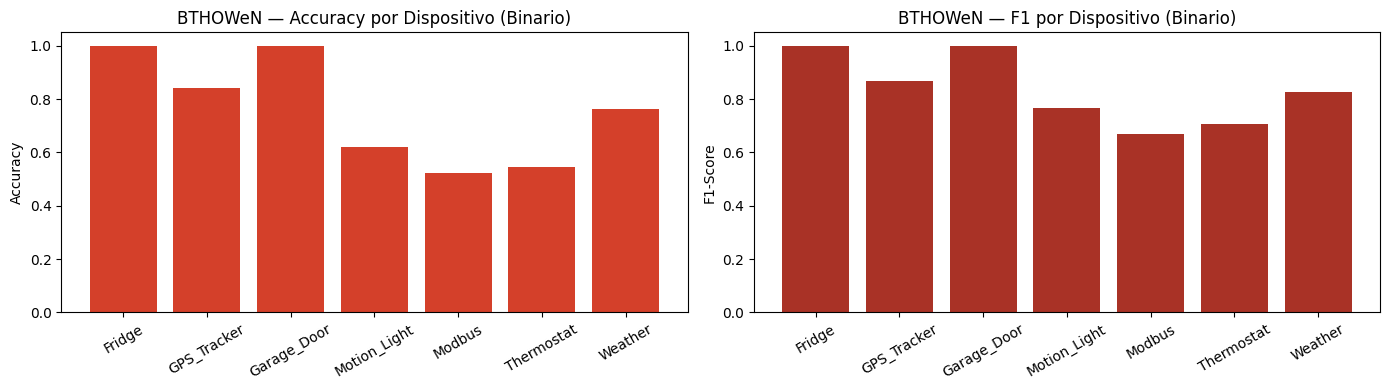

In [65]:
if all_results:
    df_res = pd.DataFrame(all_results)

    print('=== Binario ===')
    print(df_res[df_res['task']=='binary'][
        ['device','accuracy','precision','recall','f1','train_time','test_time']
    ].round(4).to_string(index=False))

    print('\n=== Multi-classe ===')
    print(df_res[df_res['task']=='multiclass'][
        ['device','accuracy','precision','recall','f1','train_time','test_time']
    ].round(4).to_string(index=False))

    df_res.to_csv('results_bthowen_toniot.csv', index=False)
    print('\nSalvo: results_bthowen_toniot.csv')

    # Grafico accuracy por dispositivo
    df_bin = df_res[df_res['task']=='binary'].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(df_bin['device'], df_bin['accuracy'], color='#D4402A')
    axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1.05)
    axes[0].set_title('BTHOWeN — Accuracy por Dispositivo (Binario)')
    axes[0].tick_params(axis='x', rotation=30)
    axes[1].bar(df_bin['device'], df_bin['f1'], color='#A93226')
    axes[1].set_ylabel('F1-Score'); axes[1].set_ylim(0, 1.05)
    axes[1].set_title('BTHOWeN — F1 por Dispositivo (Binario)')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('bthowen_devices.png', dpi=150)
    plt.show()
else:
    print('Nenhum resultado disponivel.')

## 9.1 Análise de Sensibilidade — Parâmetros BTHOWeN

Variamos `filter_entries` (tamanho do Bloom Filter) e `filter_inputs` (inputs por filtro) para avaliar o impacto na acurácia.
Cada configuração executa `train_swept_models.py` original via subprocess.

  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
Sensibilidade ao filter_entries:
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=  128  Acc=0.7285  F1=0.8088
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=  256  Acc=0.7368  F1=0.8072
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=  512  Acc=0.7681  F1=0.8286
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries= 1024  Acc=0.7467  F1=0.8129
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries= 2048  Acc=0.7562  F1=0.8199
Sensibilidade ao filter_inputs:
  int2label: {0: 'attack', 1: 'normal'

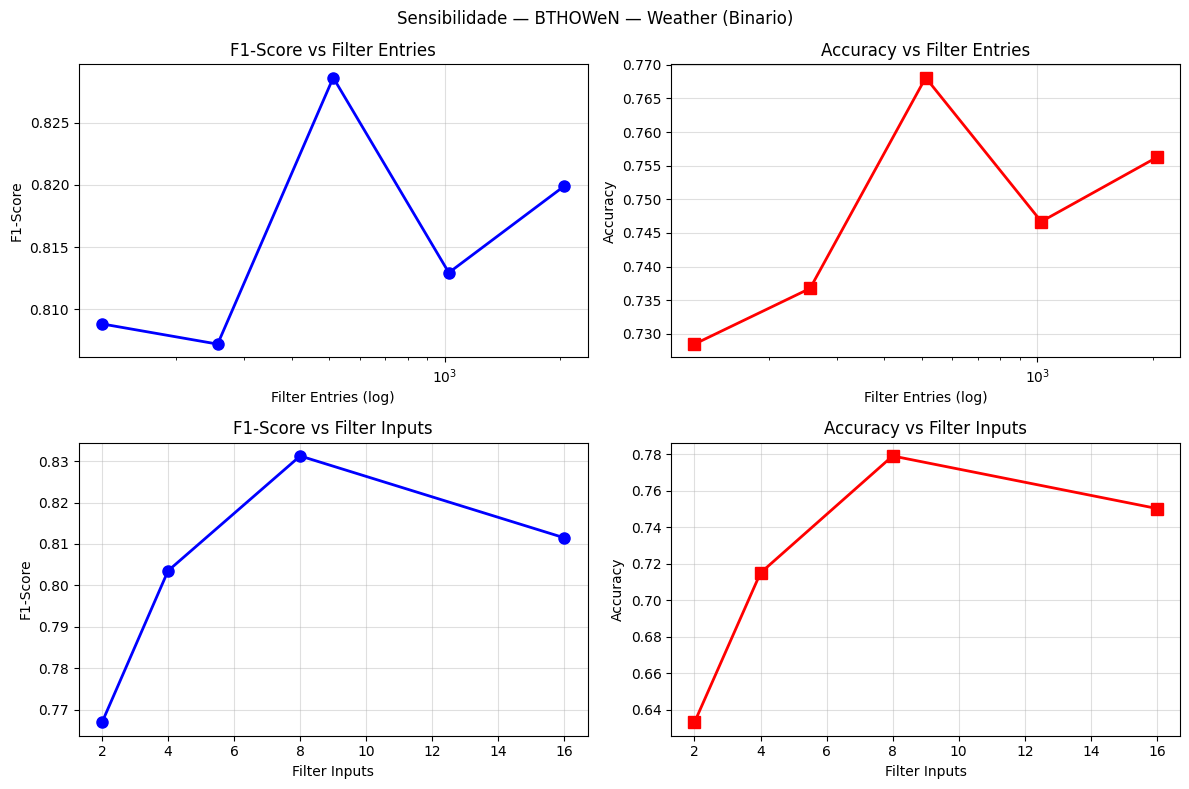

Melhor filter_entries: 512 (F1=0.8286)
Melhor filter_inputs : 8 (F1=0.8312)


In [66]:
import re as _re

def run_bthowen_params(ds_name, fi, fe, fh, bpi):
    env = os.environ.copy()
    cmd = [sys.executable,
           '/workspaces/T1_/content/BTHOWeN/software_model/train_swept_models.py',
           ds_name,
           '--filter_inputs',  str(fi),
           '--filter_entries', str(fe),
           '--filter_hashes',  str(fh),
           '--bits_per_input', str(bpi)]
    pred_dir = '/workspaces/T1_/content/BTHOWeN/software_model/predictions/' + ds_name + '_sens'
    os.makedirs(pred_dir, exist_ok=True)
    env['BTHOWEN_PRED_DIR'] = pred_dir
    r = subprocess.run(cmd, capture_output=True, text=True,
                       cwd='/workspaces/T1_/content/BTHOWeN/software_model', env=env)
    final = _re.findall(r'\((\d+),\s*\d+,\s*\d+\):\s*\d+\s*\(([\d.]+)\)', r.stdout)
    acc = float(final[-1][1]) if final else float('nan')
    f1 = float('nan')
    if os.path.exists(pred_dir + '/y_true.npy'):
        _, i2l = prepare_device(DEFAULT_DEVICE, 'binary')
        yt = np.load(pred_dir + '/y_true.npy')
        yp = np.load(pred_dir + '/y_pred.npy')
        yt_s = [i2l[int(x)] for x in yt]
        yp_s = [i2l[int(x)] for x in yp]
        f1 = f1_score(yt_s, yp_s, average='binary', pos_label='attack', zero_division=0)
    return acc, f1

ds_bin, _ = prepare_device(DEFAULT_DEVICE, 'binary')

entries_list = [128, 256, 512, 1024, 2048]
results_entries = []
print('Sensibilidade ao filter_entries:')
for fe in entries_list:
    acc, f1 = run_bthowen_params(ds_bin, FILTER_INPUTS, fe, FILTER_HASHES, BITS_PER_INPUT)
    results_entries.append({'filter_entries': fe, 'accuracy': acc, 'f1': f1})
    print(f'  entries={fe:5d}  Acc={acc:.4f}  F1={f1:.4f}')

inputs_list = [2, 4, 8, 16]
results_inputs = []
print('Sensibilidade ao filter_inputs:')
for fi in inputs_list:
    acc, f1 = run_bthowen_params(ds_bin, fi, FILTER_ENTRIES, FILTER_HASHES, BITS_PER_INPUT)
    results_inputs.append({'filter_inputs': fi, 'accuracy': acc, 'f1': f1})
    print(f'  inputs={fi:3d}  Acc={acc:.4f}  F1={f1:.4f}')

df_ent = pd.DataFrame(results_entries)
df_inp = pd.DataFrame(results_inputs)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogx(df_ent['filter_entries'], df_ent['f1'], 'bo-', linewidth=2, markersize=8)
axes[0,0].set_xlabel('Filter Entries (log)'); axes[0,0].set_ylabel('F1-Score')
axes[0,0].set_title('F1-Score vs Filter Entries'); axes[0,0].grid(True, alpha=0.4)

axes[0,1].semilogx(df_ent['filter_entries'], df_ent['accuracy'], 'rs-', linewidth=2, markersize=8)
axes[0,1].set_xlabel('Filter Entries (log)'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Accuracy vs Filter Entries'); axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(df_inp['filter_inputs'], df_inp['f1'], 'bo-', linewidth=2, markersize=8)
axes[1,0].set_xlabel('Filter Inputs'); axes[1,0].set_ylabel('F1-Score')
axes[1,0].set_title('F1-Score vs Filter Inputs'); axes[1,0].grid(True, alpha=0.4)

axes[1,1].plot(df_inp['filter_inputs'], df_inp['accuracy'], 'rs-', linewidth=2, markersize=8)
axes[1,1].set_xlabel('Filter Inputs'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('Accuracy vs Filter Inputs'); axes[1,1].grid(True, alpha=0.4)

plt.suptitle(f'Sensibilidade — BTHOWeN — {DEFAULT_DEVICE} (Binario)')
plt.tight_layout()
plt.savefig('sensitivity_bthowen.png', dpi=150)
plt.show()

best_ent = df_ent.loc[df_ent['f1'].idxmax()]
best_inp = df_inp.loc[df_inp['f1'].idxmax()]
print(f'Melhor filter_entries: {int(best_ent.filter_entries)} (F1={best_ent.f1:.4f})')
print(f'Melhor filter_inputs : {int(best_inp.filter_inputs)} (F1={best_inp.f1:.4f})')

  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
Sensibilidade ao filter_hashes:
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=    2  Acc=0.7453  F1=0.8074
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=    4  Acc=0.7579  F1=0.8223
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  entries=    6  Acc=0.7303  F1=0.8065
Sensibilidade ao BITS_PER_INPUT:
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  BITS_PER_INPUT=  8  Acc=0.7365  F1=0.8073
  int2label: {0: 'attack', 1: 'normal'}
  ok: ton_iot_weather_binary shape: (39260, 4) classes: ['attack', 'normal']
  BITS_PER_INPUT= 16  Acc=0.7449  F1=0.8182
  int2label: {0: 'attack', 1

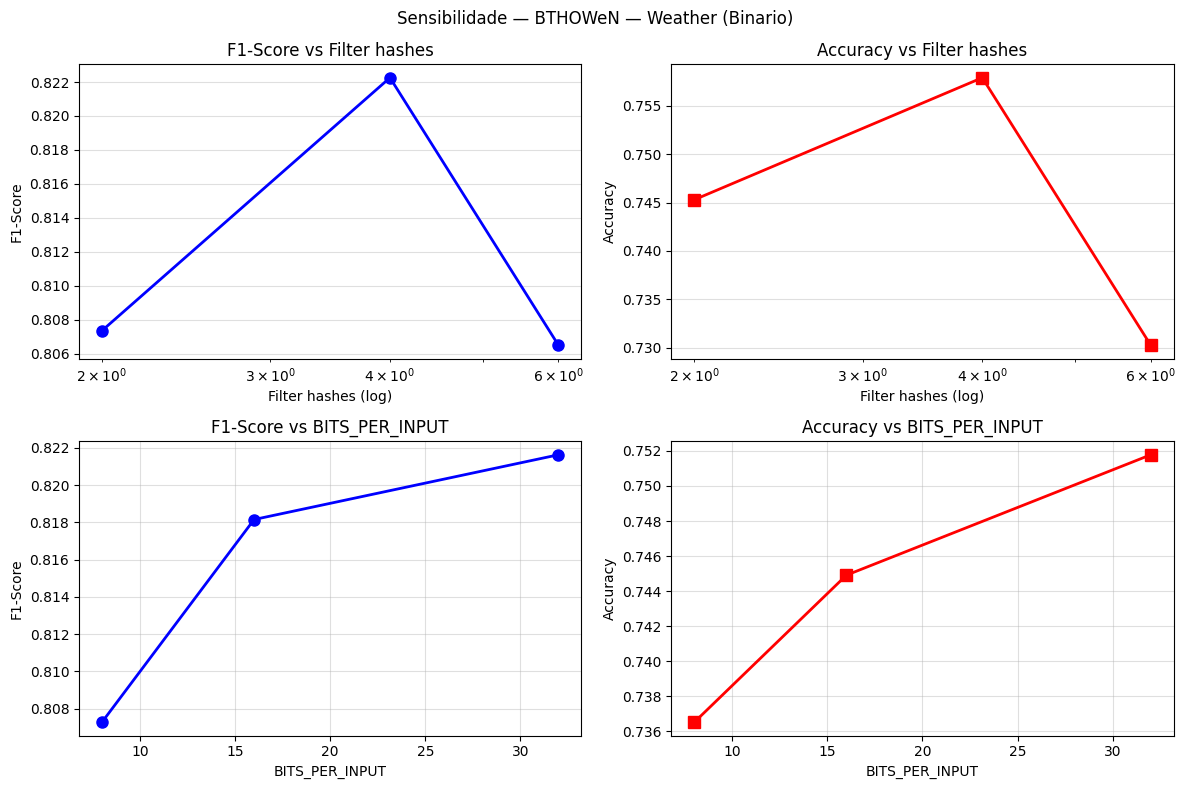

Melhor filter_hashes: 4 (F1=0.8223)
Melhor BITS_PER_INPUT : 32 (F1=0.8216)


In [74]:
import re as _re

def run_bthowen_params(ds_name, fi, fe, fh, bpi):
    env = os.environ.copy()
    cmd = [sys.executable,
           '/workspaces/T1_/content/BTHOWeN/software_model/train_swept_models.py',
           ds_name,
           '--filter_inputs',  str(fi),
           '--filter_entries', str(fe),
           '--filter_hashes',  str(fh),
           '--bits_per_input', str(bpi)]
    pred_dir = '/workspaces/T1_/content/BTHOWeN/software_model/predictions/' + ds_name + '_sens'
    os.makedirs(pred_dir, exist_ok=True)
    env['BTHOWEN_PRED_DIR'] = pred_dir
    r = subprocess.run(cmd, capture_output=True, text=True,
                       cwd='/workspaces/T1_/content/BTHOWeN/software_model', env=env)
    final = _re.findall(r'\((\d+),\s*\d+,\s*\d+\):\s*\d+\s*\(([\d.]+)\)', r.stdout)
    acc = float(final[-1][1]) if final else float('nan')
    f1 = float('nan')
    if os.path.exists(pred_dir + '/y_true.npy'):
        _, i2l = prepare_device(DEFAULT_DEVICE, 'binary')
        yt = np.load(pred_dir + '/y_true.npy')
        yp = np.load(pred_dir + '/y_pred.npy')
        yt_s = [i2l[int(x)] for x in yt]
        yp_s = [i2l[int(x)] for x in yp]
        f1 = f1_score(yt_s, yp_s, average='binary', pos_label='attack', zero_division=0)
    return acc, f1

ds_bin, _ = prepare_device(DEFAULT_DEVICE, 'binary')

hashes_list = [2,4,6]
results_hashes = []
print('Sensibilidade ao filter_hashes:')
for fh in hashes_list:
    acc, f1 = run_bthowen_params(ds_bin, FILTER_INPUTS,FILTER_ENTRIES, fh, BITS_PER_INPUT)
    results_hashes.append({'filter_hashes': fh, 'accuracy': acc, 'f1': f1})
    print(f'  entries={fh:5d}  Acc={acc:.4f}  F1={f1:.4f}')

bitsp_list = [8, 16,32]
results_bitsp = []
print('Sensibilidade ao BITS_PER_INPUT:')
for bpi in bitsp_list:
    acc, f1 = run_bthowen_params(ds_bin, FILTER_INPUTS, FILTER_ENTRIES, FILTER_HASHES, bpi)
    results_bitsp.append({'BITS_PER_INPUT': bpi, 'accuracy': acc, 'f1': f1})
    print(f'  BITS_PER_INPUT={bpi:3d}  Acc={acc:.4f}  F1={f1:.4f}')

df_ent = pd.DataFrame(results_hashes)
df_inp = pd.DataFrame(results_bitsp)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogx(df_ent['filter_hashes'], df_ent['f1'], 'bo-', linewidth=2, markersize=8)
axes[0,0].set_xlabel('Filter hashes (log)'); axes[0,0].set_ylabel('F1-Score')
axes[0,0].set_title('F1-Score vs Filter hashes'); axes[0,0].grid(True, alpha=0.4)

axes[0,1].semilogx(df_ent['filter_hashes'], df_ent['accuracy'], 'rs-', linewidth=2, markersize=8)
axes[0,1].set_xlabel('Filter hashes (log)'); axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Accuracy vs Filter hashes'); axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(df_inp['BITS_PER_INPUT'], df_inp['f1'], 'bo-', linewidth=2, markersize=8)
axes[1,0].set_xlabel('BITS_PER_INPUT'); axes[1,0].set_ylabel('F1-Score')
axes[1,0].set_title('F1-Score vs BITS_PER_INPUT'); axes[1,0].grid(True, alpha=0.4)

axes[1,1].plot(df_inp['BITS_PER_INPUT'], df_inp['accuracy'], 'rs-', linewidth=2, markersize=8)
axes[1,1].set_xlabel('BITS_PER_INPUT'); axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('Accuracy vs BITS_PER_INPUT'); axes[1,1].grid(True, alpha=0.4)

plt.suptitle(f'Sensibilidade — BTHOWeN — {DEFAULT_DEVICE} (Binario)')
plt.tight_layout()
plt.savefig('sensitivity_bthowen.png', dpi=150)
plt.show()

best_ent = df_ent.loc[df_ent['f1'].idxmax()]
best_inp = df_inp.loc[df_inp['f1'].idxmax()]
print(f'Melhor filter_hashes: {int(best_ent.filter_hashes)} (F1={best_ent.f1:.4f})')
print(f'Melhor BITS_PER_INPUT : {int(best_inp.BITS_PER_INPUT)} (F1={best_inp.f1:.4f})')

## 10. Comparação com Baselines

**Aviso:** Os valores de baseline sao do artigo Alsaedi et al. (2020), IEEE Access.
Verifique as Tabelas 10-13 antes de usar em publicacao.

 Modelo  Accuracy  Precision  Recall     F1
     LR    0.5800     0.6000  0.5900 0.5300
    LDA    0.6000     0.5900  0.6000 0.5300
    kNN    0.8100     0.8100  0.8100 0.8100
     RF    0.8400     0.8400  0.8400 0.8400
   CART    0.8700     0.8800  0.8700 0.8700
     NB    0.6900     0.7200  0.6900 0.6700
    SVM    0.6300     0.6800  0.6300 0.5500
   LSTM    0.8200     0.8200  0.8100 0.8000
BTHOWeN    0.7629     0.7469  0.9225 0.8254


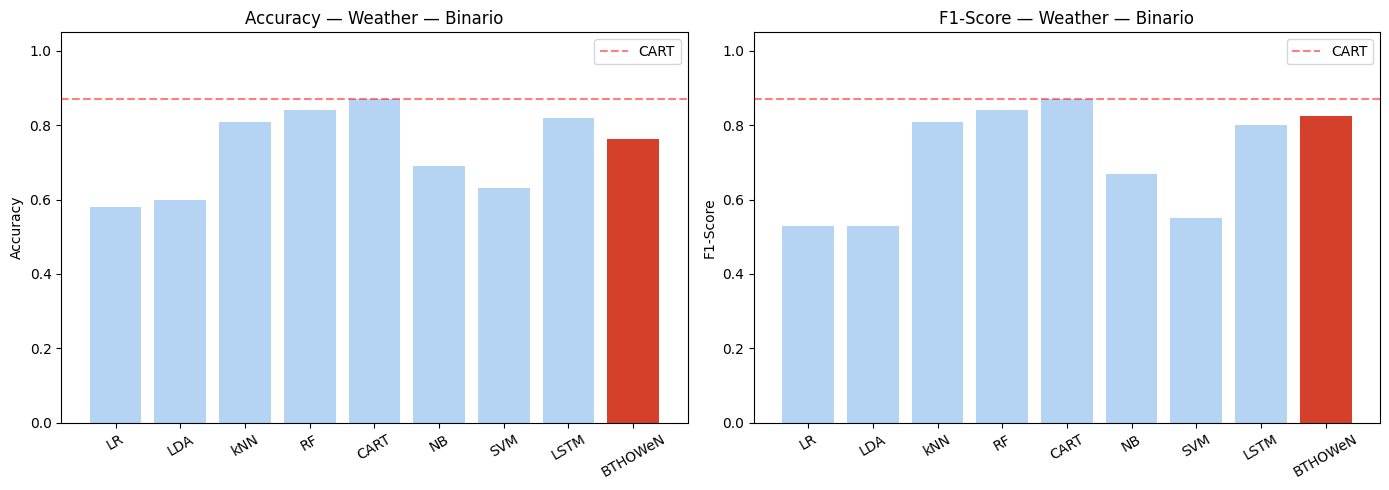

In [75]:
baseline = pd.DataFrame([
    {'Modelo': 'LR',   'Accuracy': 0.58, 'Precision': 0.60, 'Recall': 0.59, 'F1': 0.53},
    {'Modelo': 'LDA',  'Accuracy': 0.60, 'Precision': 0.59, 'Recall': 0.60, 'F1': 0.53},
    {'Modelo': 'kNN',  'Accuracy': 0.81, 'Precision': 0.81, 'Recall': 0.81, 'F1': 0.81},
    {'Modelo': 'RF',   'Accuracy': 0.84, 'Precision': 0.84, 'Recall': 0.84, 'F1': 0.84},
    {'Modelo': 'CART', 'Accuracy': 0.87, 'Precision': 0.88, 'Recall': 0.87, 'F1': 0.87},
    {'Modelo': 'NB',   'Accuracy': 0.69, 'Precision': 0.72, 'Recall': 0.69, 'F1': 0.67},
    {'Modelo': 'SVM',  'Accuracy': 0.63, 'Precision': 0.68, 'Recall': 0.63, 'F1': 0.55},
    {'Modelo': 'LSTM', 'Accuracy': 0.82, 'Precision': 0.82, 'Recall': 0.81, 'F1': 0.80},
])

if all_results:
    bin_weather = [r for r in all_results
                   if r['task']=='binary' and r.get('device')==DEFAULT_DEVICE]
    if bin_weather:
        r = bin_weather[0]
        baseline = pd.concat([baseline, pd.DataFrame([{
            'Modelo': 'BTHOWeN',
            'Accuracy': r['accuracy'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1': r['f1'],
        }])], ignore_index=True)

print(baseline.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_base = len(baseline) - (1 if 'BTHOWeN' in baseline['Modelo'].values else 0)
colors = ['#B5D4F4'] * n_base + (['#D4402A'] if 'BTHOWeN' in baseline['Modelo'].values else [])

axes[0].bar(baseline['Modelo'], baseline['Accuracy'], color=colors)
axes[0].axhline(y=0.87, color='red', linestyle='--', alpha=0.5, label='CART')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1.05)
axes[0].set_title(f'Accuracy — {DEFAULT_DEVICE} — Binario')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(baseline['Modelo'], baseline['F1'], color=colors)
axes[1].axhline(y=0.87, color='red', linestyle='--', alpha=0.5, label='CART')
axes[1].set_ylabel('F1-Score'); axes[1].set_ylim(0, 1.05)
axes[1].set_title(f'F1-Score — {DEFAULT_DEVICE} — Binario')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.savefig('comparison_bthowen.png', dpi=150)
plt.show()

## 11. Sumário Final

In [77]:
print('=== Sumario Final ===')
print('Dataset  : TON_IoT Telemetry (Alsaedi et al., 2020)')
print('Modelo   : BTHOWeN original (https://github.com/ZSusskind/BTHOWeN)')
print('Artigo   : Susskind et al., PACT 2022')
print('Pipeline : tabular_tools + modulos internos BTHOWeN + subprocess fallback')
print(f'Params   : {FILTER_INPUTS=}, {FILTER_ENTRIES=}, {FILTER_HASHES=}, {BITS_PER_INPUT=}')
print('Split    : 80/20 (test_split=0.2 em tabular_tools.py)')
print()

if all_results:
    df_f = pd.DataFrame(all_results)
    print('Accuracy media (binario)    :', df_f[df_f['task']=='binary']['accuracy'].mean().round(4))
    print('F1 media (binario)          :', df_f[df_f['task']=='binary']['f1'].mean().round(4))
    print('Accuracy media (multiclasse):', df_f[df_f['task']=='multiclass']['accuracy'].mean().round(4))
    print('F1 media (multiclasse)      :', df_f[df_f['task']=='multiclass']['f1'].mean().round(4))

=== Sumario Final ===
Dataset  : TON_IoT Telemetry (Alsaedi et al., 2020)
Modelo   : BTHOWeN original (https://github.com/ZSusskind/BTHOWeN)
Artigo   : Susskind et al., PACT 2022
Pipeline : tabular_tools + modulos internos BTHOWeN + subprocess fallback
Params   : FILTER_INPUTS=12, FILTER_ENTRIES=2048, FILTER_HASHES=4, BITS_PER_INPUT=16
Split    : 80/20 (test_split=0.2 em tabular_tools.py)

Accuracy media (binario)    : 0.7561
F1 media (binario)          : 0.8336
Accuracy media (multiclasse): 0.4914
F1 media (multiclasse)      : 0.3982
